# Tutorial: illustrate detector layouts on the focal plane

This tutorial constructs telescope models with different detector layouts and visualizes their nominal boundaries in focal-plane millimeters. It also projects the Gaia DR3 sources prepared in Tutorials 01–02 onto each focal plane.

The former `display_focal_plane()` helper is no longer part of warpfield. We reproduce its useful behavior with the public `Telescope.focal_plane()` and `focalplane_footprints()` interfaces.

## 1. Imports and plotting configuration

The plots follow the style used in `sample_01_on-sky_footprints.ipynb`: square axes, light grids, small source markers, and detector boundaries drawn as thin lines.

In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

matplotlib.rcParams['legend.frameon'] = False
matplotlib.rcParams['figure.dpi'] = 72

In [2]:
from astropy.coordinates import SkyCoord
from astropy.table import QTable
import astropy.units as u

from warpfield import (
    AstrometricCatalog,
    Detector,
    Pointing,
    SourceCatalog,
    Telescope,
)
from warpfield.footprint import focalplane_footprints
from warpfield.instrument import get_jasmine
from warpfield.projection import GnomonicProjection
from warpfield.utils import plate_scale

## 2. Load sources and define a pointing

Tutorial 01 stores the Gaia result as an `AstrometricCatalog`. For this geometric illustration, we use its ICRS positions at the catalog reference epoch and convert them into a differentiable `SourceCatalog`.

The plot is centered at the search coordinate used in Tutorials 01–02. Only sources within 0.25° are retained so that their angular extent is comparable to the detector layouts.

In [3]:
astrometry = AstrometricCatalog.from_qtable(
    QTable.read('gaia_dr3.ecsv'))

center = SkyCoord(269.267, -18.985, unit='deg', frame='icrs')
within_region = astrometry.skycoord.separation(center) < 0.25 * u.deg
source = SourceCatalog(
    astrometry.ra.degree[within_region],
    astrometry.dec.degree[within_region],
)
pointing = Pointing.from_coord(
    'icrs', center.ra, center.dec, 0.0 * u.deg)

print(f'{len(source):,} sources within 0.25 deg')

476 sources within 0.25 deg


The helper below contains only notebook-level plotting code. `project_sources()` calls the telescope forward model with a unit scale factor. `plot_focal_plane()` obtains one closed boundary array per detector and draws those boundaries in detector order.

In [4]:
def project_sources(telescope, pointing, source):
    size = len(source)
    return np.asarray(telescope.focal_plane(
        np.full(size, pointing.ra[0]),
        np.full(size, pointing.dec[0]),
        np.full(size, pointing.position_angle[0]),
        source.ra,
        source.dec,
        np.ones((size, 1)),
    ))


def plot_focal_plane(telescope, source_xy=None, title=None):
    boundaries = focalplane_footprints(telescope)
    nodes = np.concatenate(boundaries)
    limit = 1.2 * np.abs(nodes).max()

    fig, ax = plt.subplots(figsize=(6, 6))
    if source_xy is not None:
        ax.scatter(source_xy[:, 0], source_xy[:, 1], s=5)
    for detector_id, boundary in enumerate(boundaries):
        N = boundary.shape[0]
        ax.scatter(
            boundary[0, 0], boundary[0, 1],
            color=f'C{detector_id}', marker='o', s=25
        )
        ax.plot(
            boundary[:N // 4 + 1, 0], boundary[:N // 4 + 1, 1],
            color=f'C{detector_id}', lw=3
        )
        ax.plot(
            boundary[:, 0], boundary[:, 1],
            color=f'C{detector_id}', lw=1,
            label=f'Detector {detector_id}',
        )

    ax.grid(True, color='gray', alpha=0.5)
    ax.set_xlim(-limit, limit)
    ax.set_ylim(-limit, limit)
    ax.set_aspect(1.0)
    ax.set_title(title, loc='left')
    ax.set_xlabel('Focal plane X (mm)', fontsize=12)
    ax.set_ylabel('Focal plane Y (mm)', fontsize=12)
    ax.legend(loc='upper right')
    fig.tight_layout()
    return fig, ax

## 3. Construct a telescope with one 4k detector

`Telescope` accepts a sky projection, a plate scale in mm/degree, and a detector tuple. It constructs its internal `Optics`, uses identity distortion by default, and derives an imaging radius that encloses all detector corners. The public `plate_scale()` utility converts the 3.86 m focal length into the required two-axis plate scale.

The detector has 4096 × 4096 pixels with a physical pixel size of 10 μm. Geometry fields are expressed as plain numerical values in degrees, millimeters, pixels, or millimeters per pixel.

In [5]:
detector_4k = Detector(
    rotation=0.0,
    offset=[0.0, 0.0],
    pixel_scale=[0.010, 0.010],
    shape=(4096, 4096),
)
single_detector_telescope = Telescope(
    projection=GnomonicProjection(),
    plate_scale=plate_scale(3.86 * u.m),
    detectors=(detector_4k,),
)

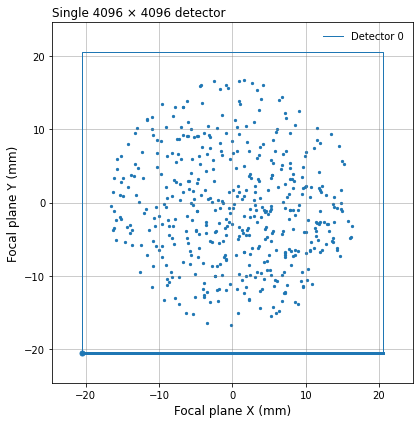

In [6]:
single_xy = project_sources(
    single_detector_telescope, pointing, source)
plot_focal_plane(
    single_detector_telescope,
    single_xy,
    title='Single 4096 × 4096 detector',
)
plt.show()

## 4. Construct a four-detector mosaic

The next model uses four 1920 × 1920 detectors with 10 μm pixels and a 3 mm gap between adjacent sensors. Each `Detector.offset` gives its center in focal-plane millimeters, while `rotation` defines its orientation.

`Telescope` requires the detector collection as a tuple. The tuple order determines detector indices and the order returned by `focalplane_footprints()`.

In [7]:
detector_shape = (1920, 1920)
pixel_size = 0.010
sensor_gap = 3.0
half_step = detector_shape[0] * pixel_size / 2 + sensor_gap / 2

offsets = (
    (-half_step, -half_step),
    (+half_step, -half_step),
    (+half_step, +half_step),
    (-half_step, +half_step),
)
rotations = (0.0, 90.0, 180.0, 270.0)
detectors = tuple(
    Detector(
        rotation=rotation,
        offset=offset,
        pixel_scale=[pixel_size, pixel_size],
        shape=detector_shape,
    )
    for rotation, offset in zip(rotations, offsets)
)

mosaic = Telescope(
    projection=GnomonicProjection(),
    plate_scale=plate_scale(4.86 * u.m),
    detectors=detectors,
)

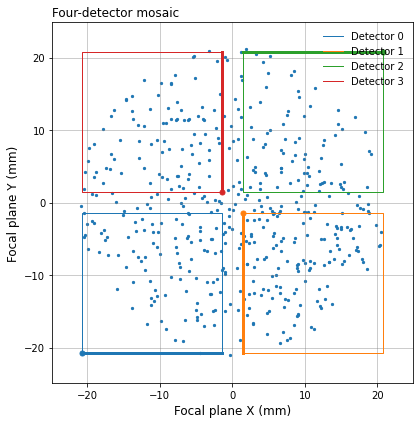

In [8]:
mosaic_xy = project_sources(mosaic, pointing, source)
plot_focal_plane(
    mosaic,
    mosaic_xy,
    title='Four-detector mosaic',
)
plt.show()

## 5. Use the JASMINE instrument preset

`get_jasmine()` provides the same nominal detector geometry and plate scale. It returns a masked `Simulator` by default; `simulator=False` requests the corresponding plain `Telescope`. Both types can be passed to the footprint and projection functions used above.

The preset additionally defines JASMINE's circular imaging radius, which is used by simulation and celestial-footprint masking.

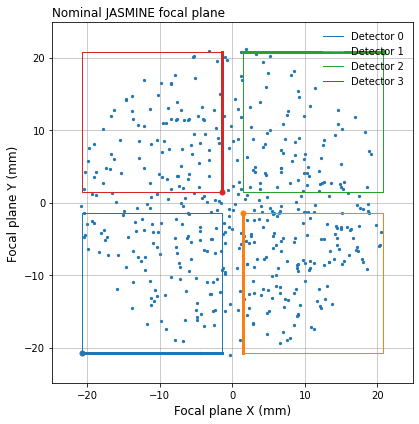

In [9]:
jasmine = get_jasmine(simulator=False)
jasmine_xy = project_sources(jasmine, pointing, source)

plot_focal_plane(
    jasmine,
    jasmine_xy,
    title='Nominal JASMINE focal plane',
)
plt.show()

## Summary

- `Telescope` constructs `Optics` from a projection, distortion, plate scale, and imaging radius.
- `Detector` defines sensor shape, pixel size, focal-plane offset, rotation, and detector distortion.
- The imaging radius is derived from the detector tuple unless explicitly supplied.
- `focalplane_footprints()` returns one nominal boundary array per detector.
- `Telescope.focal_plane()` projects source coordinates into focal-plane millimeters; detector assignment is a separate step performed by `Simulator.observe()`.